In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from pathlib import Path
from os import environ
import os
import os

ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixpoisson")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/wbic")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

dry = False # whether or not to save results

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/wbic


In [4]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [5]:
# def find_truth_by_dsid(dsid: str):
#   dgp = dgps.query(f"dsid=='{dsid}'")
#   truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
#   return truth

In [6]:
wbic_df = pd.read_csv(f"{outputdir}/wbic_bias.csv")
wbic_df.head()

,dsid,regime,n,trial,wbic,afe0,chains,draws,tune,mean_divergences,total_divergences,max_divergences,divergences_per_chain,chain_tree_depth,n_components
0,regular,50,50,0,148.380982,148.565676,1,1000,2500,0.0,0,0,[0],5,2
1,e-singular,50,50,0,139.051604,141.161511,1,1000,2500,0.0,0,0,[0],7,2
2,singular1,50,50,0,129.864095,128.380325,1,1000,2500,0.0,0,0,[0],8,2
3,singular2,50,50,0,112.492161,111.998226,1,1000,2500,0.0,0,0,[0],7,2
4,regular,50,50,0,149.435218,149.543682,1,1000,2500,0.0,0,0,[0],8,3


In [12]:
# Prep data
wbic_df['error'] = wbic_df['wbic'] - wbic_df['afe0']
wbic_df['normalized_error'] = wbic_df['error']/np.log(wbic_df['n'])
wbic_df['Model'] = wbic_df['n_components'].map({2: 'K=2', 3: 'K=3', 5: 'K=5'})
wbic_df

,dsid,regime,n,trial,wbic,afe0,chains,draws,tune,mean_divergences,total_divergences,max_divergences,divergences_per_chain,chain_tree_depth,n_components,error,Model,normalized_error
0,regular,50,50,0,148.380982,148.565676,1,1000,2500,0.0,0,0,[0],5,2,-0.184694,K=2,-0.047212
1,e-singular,50,50,0,139.051604,141.161511,1,1000,2500,0.0,0,0,[0],7,2,-2.109907,K=2,-0.539339
2,singular1,50,50,0,129.864095,128.380325,1,1000,2500,0.0,0,0,[0],8,2,1.483769,K=2,0.379284
3,singular2,50,50,0,112.492161,111.998226,1,1000,2500,0.0,0,0,[0],7,2,0.493936,K=2,0.126261
4,regular,50,50,0,149.435218,149.543682,1,1000,2500,0.0,0,0,[0],8,3,-0.108464,K=3,-0.027726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,singular2,5000,5000,59,11029.398172,11029.595612,1,1000,2500,0.0,0,0,[0],9,3,-0.197440,K=3,-0.023181
2156,regular,5000,5000,59,14839.062765,14841.562560,1,1000,2500,0.0,0,0,[0],10,5,-2.499796,K=5,-0.293500
2157,e-singular,5000,5000,59,13635.729496,13646.187149,1,1000,2500,0.0,0,0,[0],10,5,-10.457652,K=5,-1.227828
2158,singular1,5000,5000,59,12828.083409,12827.911420,1,1000,2500,0.0,0,0,[0],10,5,0.171989,K=5,0.020193


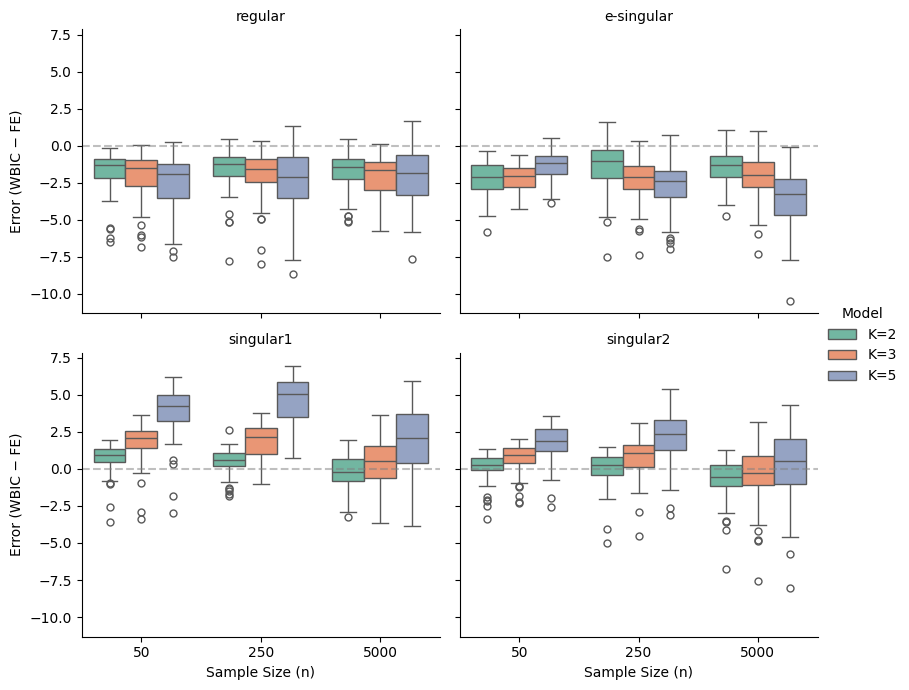

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Box plot using catplot with shared y-axis
g = sns.catplot(
    data=wbic_df,
    x='n',
    y='error',
    hue='Model',
    col='dsid',
    kind='box',
    col_wrap=2,
    sharey=True,
    height=3.5,
    aspect=1.2,
    palette='Set2'
)

# Add reference line at 0
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

g.set_axis_labels('Sample Size (n)', 'Error (WBIC − FE)')
g.set_titles(col_template='{col_name}')

# plt.tight_layout()
# plt.savefig('wbic_error_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

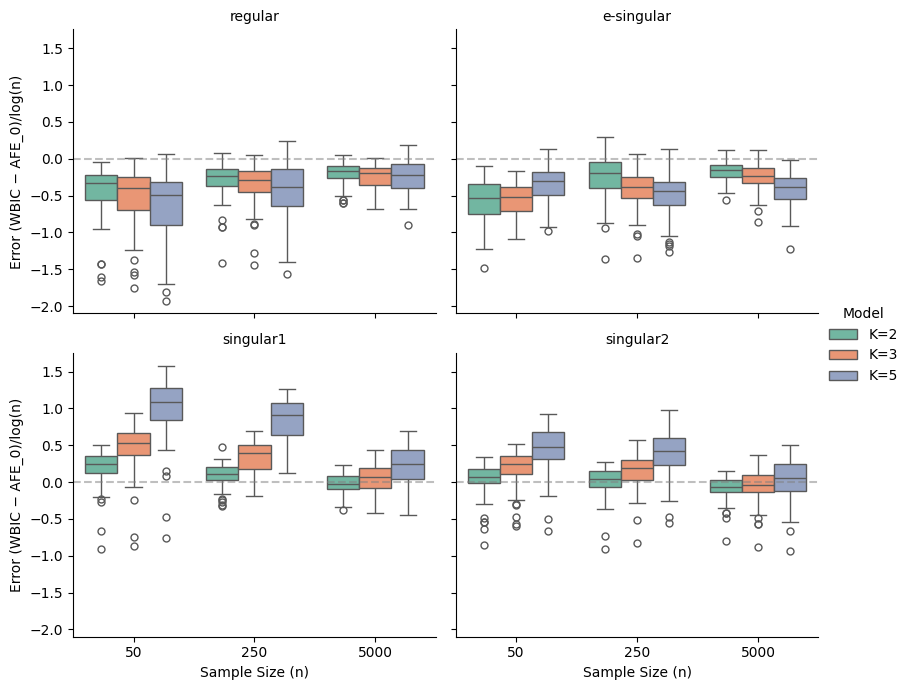

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Box plot using catplot with shared y-axis
g = sns.catplot(
    data=wbic_df,
    x='n',
    y='normalized_error',
    hue='Model',
    col='dsid',
    kind='box',
    col_wrap=2,
    sharey=True,
    height=3.5,
    aspect=1.2,
    palette='Set2'
)

# Add reference line at 0
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

g.set_axis_labels('Sample Size (n)', 'Error (WBIC − AFE_0)/log(n)')
g.set_titles(col_template='{col_name}')

# plt.tight_layout()
# plt.savefig('wbic_error_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

Estimated convergence rates (RMSE ~ n^(-α)):
      dsid Model     alpha  intercept  r_squared
e-singular   K=2  0.056884   1.111975   0.893043
e-singular   K=3 -0.022260   0.816558   0.311534
e-singular   K=5 -0.180481  -0.052266   0.860795
   regular   K=2  0.010196   0.841893   0.581730
   regular   K=3  0.011072   0.989738   0.999130
   regular   K=5  0.022217   1.224771   0.835720
 singular1   K=2 -0.005108   0.107376   0.011615
 singular1   K=3  0.062510   1.080846   0.923873
 singular1   K=5  0.088062   1.901360   0.641907
 singular2   K=2 -0.117088  -0.497744   1.000000
 singular2   K=3 -0.100948  -0.162611   0.971697
 singular2   K=5 -0.017898   0.805077   0.080940


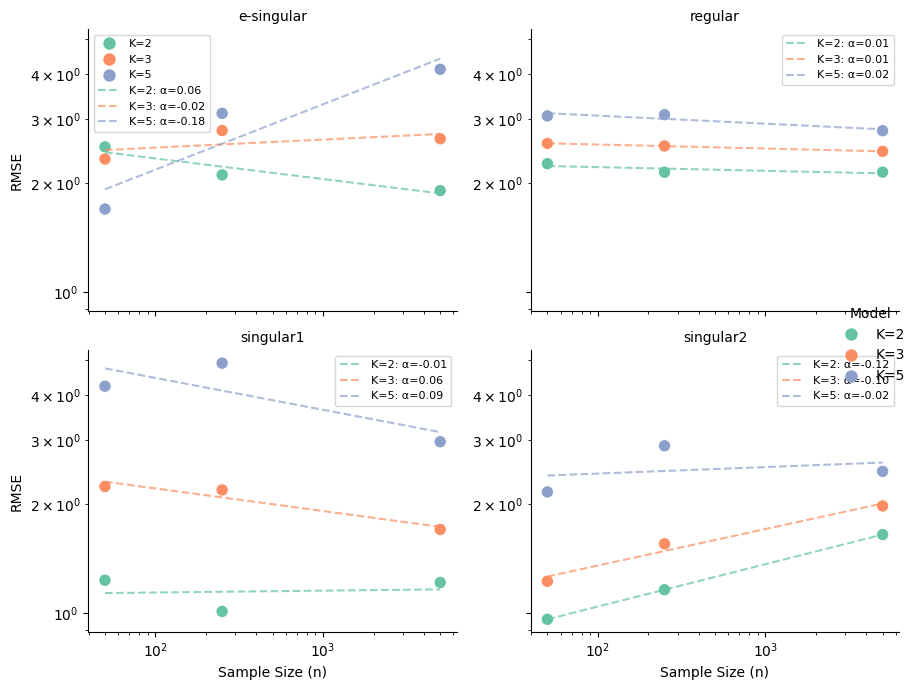


Convergence rates summary:
Model         K=2    K=3    K=5
dsid                           
e-singular  0.057 -0.022 -0.180
regular     0.010  0.011  0.022
singular1  -0.005  0.063  0.088
singular2  -0.117 -0.101 -0.018


In [10]:
from scipy import stats

# Aggregate: RMSE per (dsid, n, model)
summary = wbic_df.groupby(['dsid', 'n', 'Model']).agg(
    rmse=('error', lambda x: np.sqrt(np.mean(x**2)))
).reset_index()

# Log transform for regression
summary['log_n'] = np.log(summary['n'])
summary['log_rmse'] = np.log(summary['rmse'])

# Fit convergence rate for each (dsid, Model)
def fit_rate(group):
    slope, intercept, r, p, se = stats.linregress(group['log_n'], group['log_rmse'])
    return pd.Series({
        'alpha': -slope,
        'intercept': intercept,
        'r_squared': r**2
    })

rates = summary.groupby(['dsid', 'Model']).apply(fit_rate).reset_index()
print("Estimated convergence rates (RMSE ~ n^(-α)):")
print(rates.to_string(index=False))

# Plot using relplot (continuous x-axis)
g = sns.relplot(
    data=summary,
    x='n',
    y='rmse',
    hue='Model',
    col='dsid',
    kind='scatter',
    col_wrap=2,
    height=3.5,
    aspect=1.2,
    palette='Set2',
    s=80
)

# Add fitted convergence lines
for ax, dsid in zip(g.axes.flat, summary['dsid'].unique()):
    subset = summary[summary['dsid'] == dsid]
    n_vals = sorted(subset['n'].unique())
    n_range = np.linspace(min(n_vals), max(n_vals), 100)
    
    for model, color in zip(['K=2', 'K=3', 'K=5'], sns.color_palette('Set2')):
        rate_row = rates[(rates['dsid'] == dsid) & (rates['Model'] == model)]
        if len(rate_row) == 0:
            continue
        alpha = rate_row['alpha'].values[0]
        intercept = rate_row['intercept'].values[0]
        
        fitted = np.exp(intercept) * n_range ** (-alpha)
        ax.plot(n_range, fitted, color=color, linestyle='--', alpha=0.7,
                label=f'{model}: α={alpha:.2f}')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=8)

g.set_axis_labels('Sample Size (n)', 'RMSE')
g.set_titles(col_template='{col_name}')

plt.tight_layout()
plt.show()

print("\nConvergence rates summary:")
pivot = rates.pivot(index='dsid', columns='Model', values='alpha')
print(pivot.round(3))